In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as const

from accomp import class_Molecule
from accomp import class_Star
from accomp import class_Disk

Create an object of class Star. This is often the first step because the host star sets the reference composition and determines disk properties


In [2]:
st = class_Star.Star()

Creating a Molecule Dict. It contains a dictionary of class Molecule objects. The easiest way to set up this dictionary is to use the set_default_composition routine, which includes most of the common molecules of major elemental species.

In [3]:
mol_dict = class_Molecule.MoleculeDict(st)
mol_dict.set_default_composition()

Putting remaining element fraction for C in refractory
Putting remaining element fraction for O in refractory
Putting remaining element fraction for S in refractory


The attribute summed_abundances lets you check whether elemental abundances assigned to different molecules add up to unity. This should be true as long as there is no extra enrichment of solids or gas.

In [4]:
mol_dict.summed_abundances

Counter({'C': 1.0,
         'O': 1.0,
         'N': 1.0,
         'S': 1.0,
         'Ne': 1.0,
         'Ar': 1.0,
         'Na': 1.0,
         'Si': 1.0,
         'Mg': 1.0,
         'Fe': 1.0,
         'Ni': 1.0,
         'Al': 1.0,
         'Ca': 1.0})

The attribute elem_dict lets one see the molecular make up of a given element.

In [5]:
mol_dict.elem_dict

{'C': {'CO': 0.4, 'CO2': 0.1, 'C_refactory': 0.5},
 'O': {'CO': 0.23553746214223634,
  'CO2': 0.11776873107111817,
  'H2O': 0.45,
  'O_refractory': 0.1966938067866455},
 'N': {'N2': 0.6, 'NH4SH': 0.15, 'NH3': 0.25},
 'S': {'NH4SH': 0.7692920759870473,
  'H2S': 0.1,
  'S_refactory': 0.13070792401295273},
 'Ne': {'Ne': 1.0},
 'Ar': {'Ar': 1.0},
 'Na': {'Na': 1.0},
 'Si': {'Si': 1.0},
 'Mg': {'Mg': 1.0},
 'Fe': {'Fe': 1.0},
 'Ni': {'Ni': 1.0},
 'Al': {'Al': 1.0},
 'Ca': {'Ca': 1.0}}

You can print a sorted list of different molecules/elements and their corresponding condensation temperature

In [6]:
mol_dict.get_mol_Tcond()

{'Al': 2000.0,
 'Ca': 2000.0,
 'Si': 1600.0,
 'Mg': 1600.0,
 'Fe': 1600.0,
 'Ni': 1600.0,
 'O_refractory': 1600.0,
 'Na': 1100.0,
 'NH4SH': 300.0,
 'C_refactory': 300.0,
 'S_refactory': 300.0,
 'H2O': 170.0,
 'H2S': 90.0,
 'CO2': 70.0,
 'NH3': 70.0,
 'CO': 30.0,
 'N2': 25.0,
 'Ne': 25.0,
 'Ar': 25.0}

If you want to keep the default composition dictionary but change the condensation temperature of particular molecule, you can simply do so by assigning the new condensation temperature to the molecule in the dictionary.

In [7]:
print('CO\'s condensation temperature:' + str(mol_dict.molecule_dict['CO'].condensation_T) + 'K')

#change CO's condensation temperature to 25 K
mol_dict.molecule_dict['CO'].condensation_T = 25.

print('CO\'s condensation temperature:' + str(mol_dict.molecule_dict['CO'].condensation_T) + 'K')

CO's condensation temperature:30.0K
CO's condensation temperature:25.0K


You can completely customize the make up of the Molecule Dict object and choose not to use the default composition. But there are a few things to be careful about.  

In [8]:
mol_dict_custom = class_Molecule.MoleculeDict(st)

#create molecules you want to add to this dictionary
mol_dict_custom.molecule_dict['H2O'] = class_Molecule.Molecule('H2O', 170.)
mol_dict_custom.molecule_dict['H2O'].set_elem_fraction(st, 'O', 0.45)

mol_dict_custom.molecule_dict['CO'] = class_Molecule.Molecule('CO', 30.)
mol_dict_custom.molecule_dict['CO'].set_elem_fraction(st, 'C', 0.4)

mol_dict_custom.molecule_dict['CO2'] = class_Molecule.Molecule('CO2', 70.)
mol_dict_custom.molecule_dict['CO2'].set_elem_fraction(st, 'C', 0.2)

mol_dict_custom.molecule_dict['N2'] = class_Molecule.Molecule('N2', 25.)
mol_dict_custom.molecule_dict['N2'].set_elem_fraction(st, 'N', 0.6)

mol_dict_custom.molecule_dict['C2H2N8'] = class_Molecule.Molecule('C2H2N8', 100.)
mol_dict_custom.molecule_dict['C2H2N8'].set_elem_fraction(st, 'C', 0.02)
#higher values of elem_frac for C for this molecule would through an error if it leads to too much N

After any customization, it is important to ensure that elemental abundance fractions add up to unity. For volatile species, there is a function set up to do this and assign any remaining elemental inventory to refractory species.

In [9]:
mol_dict_custom.catch_remaining_fraction()

Putting remaining element fraction for O in refractory
Putting remaining element fraction for C in refractory
Putting remaining element fraction for N in refractory


In [10]:
#updated view of the molecule dictionary
mol_dict_custom.elem_dict

{'O': {'H2O': 0.45,
  'CO': 0.23553746214223634,
  'CO2': 0.23553746214223634,
  'O_refractory': 0.07892507571552732},
 'C': {'CO': 0.4,
  'CO2': 0.2,
  'C2H2N8': 0.02,
  'C_refactory': 0.3799999999999999},
 'N': {'N2': 0.6,
  'C2H2N8': 0.3412636150412747,
  'N_refactory': 0.05873638495872524}}

We can add species that are enhanced in the disk, say due to pebble drift and evaporation. To do so, we use the EnrichedMolecule class, which does not enfore that elemental fractions add up to unity.

In [11]:
co_enrich = class_Molecule.EnrichedMolecule('CO', 30.)
co_enrich.set_elem_fraction(st, 'C', 5.)

co2_enrich = class_Molecule.EnrichedMolecule('CO2', 70.)
co2_enrich.set_elem_fraction(st, 'C', 2.)

We add the enriched molecules with a modified key to MoleculeDict so that they don't substitute the base case molecules such as CO and CO2.

In [12]:
mol_dict_custom.molecule_dict['CO_enrich'] = co_enrich
mol_dict_custom.molecule_dict['CO2_enrich'] = co2_enrich

Importing a disk instance, getting the location of condensation fronts, and calculating the composition of solids and gas at a particular temperature.

In [13]:
disk = class_Disk.Disk(st, r_min=0.01, n_r=100)
disk.set_temp_struct()

In [14]:
disk.get_condensation_locations(mol_dict_custom)

{'O_refractory': 0.0992125657480125,
 'C_refactory': 0.6372987189486499,
 'N_refactory': 0.6372987189486499,
 'H2O': 1.197907863731057,
 'C2H2N8': 2.5756070457449964,
 'CO2': 5.919942808420244,
 'CO2_enrich': 5.919942808420244,
 'CO': 42.74939866691744,
 'CO_enrich': 42.74939866691744,
 'N2': 65.41634134195698}

In [15]:
disk.get_solid_gas_composition(mol_dict_custom, temp=50.)

({'C': 2.5999999999999996, 'O': 3.119837159280127, 'N': 0.39999999999999997},
 {'C': 5.4, 'O': 3.1797557389201905, 'N': 0.6})

We can modify the extent of enrichment and recalculate the composition of solids and gas.

In [16]:
mol_dict_custom.molecule_dict['CO_enrich'].set_elem_fraction(st, 'C', 3.)
mol_dict_custom.molecule_dict['CO2_enrich'].set_elem_fraction(st, 'C', 2.5)

In [17]:
disk.get_solid_gas_composition(mol_dict_custom, temp=25.)

({'C': 6.5, 'O': 5.710749242844726, 'N': 0.39999999999999997},
 {'C': 0.0, 'O': 0.0, 'N': 0.6})

Let us calculate the composition of solids and gas as a function of orbital distance from the star and plot these values

In [18]:
disk.get_condensation_locations(mol_dict_custom)

{'O_refractory': 0.0992125657480125,
 'C_refactory': 0.6372987189486499,
 'N_refactory': 0.6372987189486499,
 'H2O': 1.197907863731057,
 'C2H2N8': 2.5756070457449964,
 'CO2': 5.919942808420244,
 'CO2_enrich': 5.919942808420244,
 'CO': 42.74939866691744,
 'CO_enrich': 42.74939866691744,
 'N2': 65.41634134195698}

In [19]:
solids_list = []
gas_list = []

#along with the pre-set semimajor axis values, it is useful to calculate this composition at the location of the snowlines so that the composition transitions are vertical in this plot

orb_dist = np.copy(disk.semimajor / const.au.cgs.value)
snowlines = disk.get_condensation_locations(mol_dict_custom)
snowlines = np.array([snowlines[k] for k in snowlines.keys()])
orb_dist = np.append(orb_dist, snowlines)
orb_dist = np.sort(orb_dist)

for i in range(len(orb_dist)):
    solids, gas = disk.get_solid_gas_composition(mol_dict_custom, location=orb_dist[i])
    solids_list.append(solids)
    gas_list.append(gas)

solids_location = {k: np.array([solids_list[r][k] for r in range(len(orb_dist))]) for k in mol_dict_custom.summed_abundances.keys()}
gas_location = {k: np.array([gas_list[r][k] for r in range(len(orb_dist))]) for k in mol_dict_custom.summed_abundances.keys()}

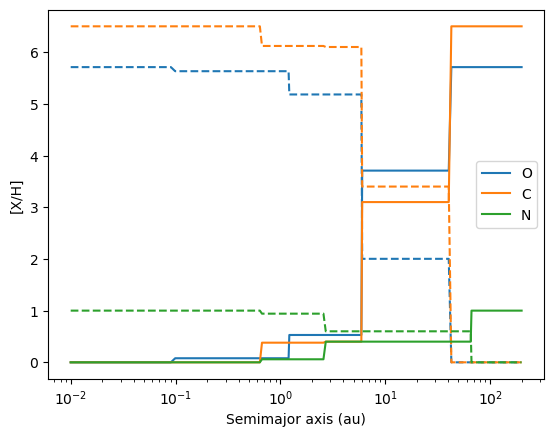

In [20]:
plt.figure()

for i, k in enumerate(solids_location.keys()):
    plt.plot(orb_dist, solids_location[k], color='C' + str(i), label=k)
    plt.plot(orb_dist, gas_location[k], ls='--', color='C' + str(i))

plt.xscale('log')
plt.xlabel('Semimajor axis (au)')
plt.ylabel('[X/H]')
plt.legend()

The current implementation of EnrichedMolecule is quite simple and binary - the molecule is enriched uniformly everywhere either in gas phase or solid phase depending on the local temperature. More sophisticated considerations where the degree of enrichment varies spatially will be added in a future version of the code.